# Inference and robustness

With 11 groups the usual clustered standard errors are not reliable. The bootstrap resamples whole groups; the permutation test shuffles treatment years across groups.

**Expected:** bootstrap SE around 0.129. The permutation distribution centres near -0.16 and lies almost entirely below zero, which means the observed -0.21 is unremarkable and the estimate is not tied to the timing of the programme.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd

import config
import estimation

import figures
figures.setup()

In [2]:
panel_df = pd.read_csv(config.WORK / 'panel_narrow.csv')
pair = pd.read_csv(config.WORK / 'pair_panel.csv')
observed = float(estimation.cluster_fit(pair, estimation.MAIN).params['post'])
print(f'observed: {observed:.4f}')

observed: -0.2096


In [3]:
boot = estimation.bootstrap(pair)
perm = estimation.randomization_inference(pair)
pd.DataFrame([
    estimation.describe_draws(boot, observed, 'cluster bootstrap'),
    estimation.describe_draws(perm, observed, 'randomization inference', centre='zero'),
]).round(4)

,spec,coef,se,lo,hi,p,null_distribution,draws
0,cluster bootstrap,-0.2096,0.1286,-0.4612,0.0453,0.1111,False,999
1,randomization inference,-0.2096,0.0693,-0.3006,-0.0302,0.2505,True,2000


saved randomization_inference.pdf and randomization_inference.png


(<Figure size 480x264 with 1 Axes>,
 <Axes: xlabel='Coefficient under permuted treatment timing', ylabel='Permutations'>)

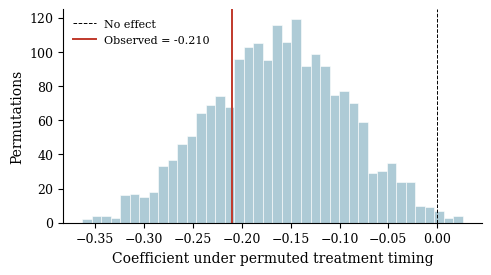

In [4]:
figures.permutation(perm, observed)

In [5]:
windows = estimation.window_sensitivity(pair)
windows.round(4)

,spec,coef,se,p,n
0,rel_year within +/-5,0.0141,0.1297,0.9135,110
1,rel_year within +/-8,-0.0503,0.1589,0.7517,151
2,rel_year within +/-12,-0.1458,0.1523,0.3384,198
3,full panel,-0.2096,0.1350,0.1206,363


In [6]:
bright = estimation.brightness_threshold(pair)
bright.round(4)

,spec,coef,se,p,n,groups
0,dimmest side above 0.0,-0.2096,0.1350,0.1206,363,11
1,dimmest side above 0.01,-0.2347,0.1756,0.1814,264,8
2,dimmest side above 0.05,-0.2347,0.1756,0.1814,264,8
3,dimmest side above 0.1,-0.2347,0.1756,0.1814,264,8


In [7]:
offsets = estimation.offset_sensitivity(panel_df)
offsets.round(4)

pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups


,spec,coef,se,p,n
0,offset c = 0.001,-0.3027,0.2482,0.2226,363
1,offset c = 0.01,-0.2096,0.1350,0.1206,363
2,offset c = 0.1,-0.1394,0.0666,0.0363,363
3,offset c = 1.0,-0.0703,0.0331,0.0337,363


In [8]:
windows.to_csv(config.OUT / "window_sensitivity.csv", index=False)
bright.to_csv(config.OUT / "brightness_threshold.csv", index=False)
offsets.to_csv(config.OUT / "offset_sensitivity.csv", index=False)
print("saved")

pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups
saved


In [9]:
pd.DataFrame([
    estimation.describe_draws(boot, observed, 'cluster bootstrap'),
    estimation.describe_draws(perm, observed, 'randomization inference', centre='zero'),
]).to_csv(config.OUT / "inference.csv", index=False)
print("saved")

saved


In [10]:
spells = estimation.programme_spells(panel_df)
spells.to_csv(config.OUT / "programme_spells.csv", index=False)
spells

,G1ID,country,name,n_spells,spells
0,124,CG,Bambundu,2,"2003-2005, 2010-2012"
1,173,ET,Berta,4,"1993, 1997, 1999, 2001-2004"
2,224,CM,Bute,2,"1998-2004, 2006-2008"
3,321,CD,Dago,5,"1996-1998, 2000-2003, 2005, 2008, 2015-2017"
4,503,CM,Jukun and Idoma,2,"1998-2004, 2006-2008"
5,574,ET,Koma,4,"1993, 1997, 1999, 2001-2004"
6,685,CM,"Mandara (incl. Matakam, Gidar)",2,"1998-2004, 2006-2008"
7,1095,CM,Tikar,2,"1998-2004, 2006-2008"
8,1101,CM,"Tiv (incl. Ekoi, Boki, Jarawas)",2,"1998-2004, 2006-2008"
9,1192,ZA,"Waluchazi (incl. Waluimbe, Wambundu)",4,"1996-1997, 1999-2002, 2005-2007, 2009-2011"


In [11]:
pair_a = estimation.add_active(pair, panel_df)
onoff = estimation.on_off_specifications(pair_a)
onoff.to_csv(config.OUT / "on_off.csv", index=False)
onoff.round(4)

,spec,coef,se,p,n
0,active programme,0.1202,0.1445,0.4056,363
1,"post entry, no active programme",-0.2737,0.1613,0.0897,363
2,additional effect while active,0.1792,0.1634,0.2728,363
3,entry (34 events),0.1076,0.1299,0.4075,352
4,exit (34 events),0.0022,0.0692,0.9746,352


In [12]:
for formula, term in [("gap ~ post + active + C(G1ID)", "post"),
                      ("gap ~ post + active + C(G1ID)", "active"),
                      ("d_gap ~ entry + exit + C(G1ID)", "entry"),
                      ("d_gap ~ entry + exit + C(G1ID)", "exit")]:
    data = pair_a.dropna(subset=["d_gap"]) if formula.startswith("d_gap") else pair_a
    d = estimation.bootstrap(data, formula=formula, term=term)
    lo, hi = np.percentile(d, [2.5, 97.5])
    print(f"{term:>7}: SE {d.std(ddof=1):.4f}  CI [{lo:.3f}, {hi:.3f}]")

   post: SE 0.1523  CI [-0.551, 0.037]
 active: SE 0.1557  CI [-0.145, 0.460]
  entry: SE 0.1295  CI [-0.134, 0.368]
   exit: SE 0.0690  CI [-0.120, 0.149]
